In [30]:
#Import necessary libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.layers import LSTM,Dense
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
#Load necessary datasets and preprocess them
df=pd.read_csv("Nifty.csv",index_col="Date",parse_dates=True,date_format='%Y-%m-%d')
df.head()
df=df[['Open','High','Low','Close']]
scaler=MinMaxScaler()
df_scaled=scaler.fit_transform(df)
look_back=10
x,y=[],[]
for i in range(len(df_scaled)-look_back):
    x.append(df_scaled[i:i+look_back])
    y.append(df_scaled[i+look_back][3])
#Split the datasets
x=np.array(x)
y=np.array(y)
split=int(len(x)*0.8)
x_train,x_test=x[:split],x[split:]
y_train,y_test=y[:split],y[split:]

In [40]:
#Train the model
model=Sequential([
    LSTM(64,input_shape=(10,4)),
    Dense(32,activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam',loss='mean_squared_error')
history=model.fit(x_train,y_train,epochs=20)
y_pred=model.predict(x_test)
mse=mean_squared_error(y_test,y_pred)

Epoch 1/20


C:\Users\Namitha Anna Koshy\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0066
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.6533e-05
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.4893e-05
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.3335e-05
Epoch 5/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.7309e-05
Epoch 6/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.4099e-05
Epoch 7/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.0221e-05
Epoch 8/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.0065e-05
Epoch 9/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.1646e-05
Epoch 10/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.2285e-05
Epoch 11/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.6111e-05
Epoch 12/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.9015e-05
Epoch 13/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.1238e-05
Epoch 14/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.6529e-05
Epoch 15/20
148/

The mean squared error is 0.00003


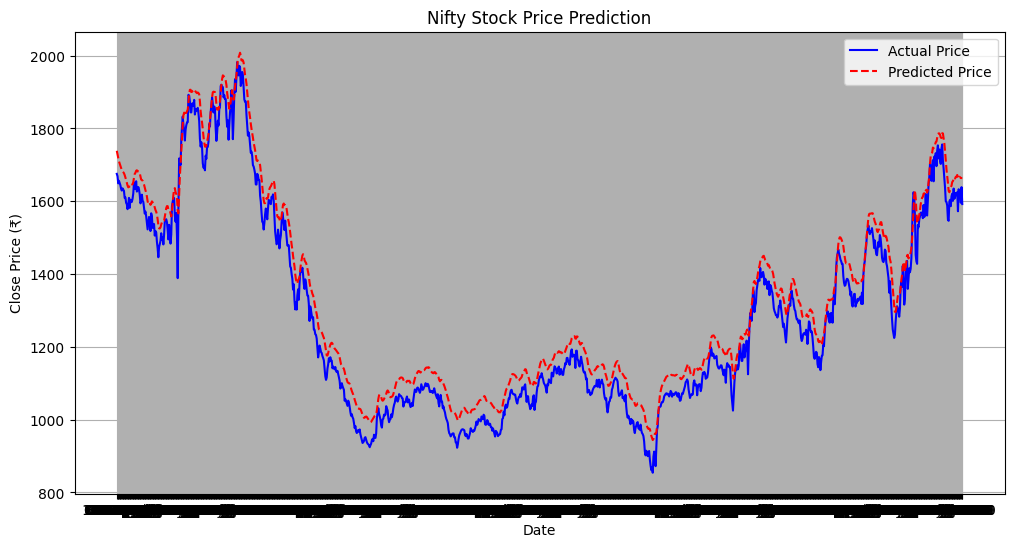

In [41]:
# Plot with values
print(f'The mean squared error is {mse:.5f}')
plt.figure(figsize=(12, 6))
plt.plot(test_dates, y_test_actual, label='Actual Price', color='blue')
plt.plot(test_dates, y_pred_actual, label='Predicted Price', color='red', linestyle='--')
plt.title('Nifty Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Close Price (₹)')
plt.legend()
plt.grid(True)
plt.show()